# Pairing-distance–stratified analysis of viral RNA structures

Pool base-pair distances (`j − i`) from reference structures in `viruses.fasta`, summarize their genome-wide distribution, and evaluate method Recall within pairing-distance strata (`<200`, `200–499`, `500–999`, `≥1000` nt).


## Setup


In [1]:
import os
import re

import numpy as np
import pandas as pd
from Bio import SeqIO
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm

FASTA_PATH = "../data/viruses.fasta"
FIG_DIR = "fig"
BIN_SIZE = 100

PREFERRED_FONT = "Arial"
FALLBACK_FONT = "DejaVu Sans"
available_fonts = {f.name.lower() for f in fm.fontManager.ttflist}
chosen_font = PREFERRED_FONT if PREFERRED_FONT.lower() in available_fonts else FALLBACK_FONT

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PREFERRED_FONT, FALLBACK_FONT, "Liberation Sans", "Nimbus Sans", "sans-serif"]
plt.rcParams["font.size"] = 16
plt.rcParams["axes.unicode_minus"] = False

os.makedirs(FIG_DIR, exist_ok=True)


## Helper functions


In [2]:
def split_fasta_seq(seq_str):
    """Split SeqIO-merged sequence+structure string into RNA sequence and dot-bracket."""
    ind = re.search(r"[.()\[\]{}<>]", seq_str).start()
    seq = seq_str[:ind].lower().replace("t", "u")
    struct = seq_str[ind : ind * 2]
    return seq, struct

def clean_structure(struct):
    """Keep only `(`, `)`, `.` (drop pseudoknot brackets; matches f1_mas_computation)."""
    struct_clean = struct
    for c in np.unique(list(struct)):
        if c not in ["(", ")", "."]:
            struct_clean = struct_clean.replace(c, ".")
    return struct_clean

def dot_bracket_to_pairs(structure):
    """Convert `()` pairs in dot-bracket to 0-indexed `(i, j)`; other symbols are ignored.

    Returns `(pairs, None)` on success, or `(None, error_message)` on failure.
    """
    pairs = []
    stack = []

    for i, char in enumerate(structure):
        if char == "(":
            stack.append(i)
        elif char == ")":
            if not stack:
                return None, f"Unmatched bracket: ')' at position {i + 1}"
            j = stack.pop()
            pairs.append((j, i))

    if stack:
        return None, f"Unmatched bracket: '(' at position {stack[0] + 1}"

    return pairs, None


def load_viruses(fasta_path):
    """Load `{id: (seq, struct)}` from a FASTA with interleaved sequence and structure lines."""
    viruses = {}
    for rec in SeqIO.parse(fasta_path, "fasta"):
        viruses[rec.id] = split_fasta_seq(str(rec.seq))
    return viruses


## Pairing-distance distribution


In [3]:
viruses = load_viruses(FASTA_PATH)

pair_distances_by_id = {}
all_pair_distances = []

for rna_id, (_, struct) in viruses.items():
    pairs, error = dot_bracket_to_pairs(clean_structure(struct))
    if error:
        print(f"Warning: failed to parse structure for {rna_id}: {error}")
        continue

    distances = [j - i for i, j in pairs]
    pair_distances_by_id[rna_id] = distances
    all_pair_distances.extend(distances)

all_pair_distances = np.array(all_pair_distances)
print(
    f"{len(pair_distances_by_id)} / {len(viruses)} sequences; "
    f"{len(all_pair_distances)} base pairs; "
    f"distance range {all_pair_distances.min()}–{all_pair_distances.max()} nt"
)


28 / 28 sequences; 67484 base pairs; distance range 4–10720 nt


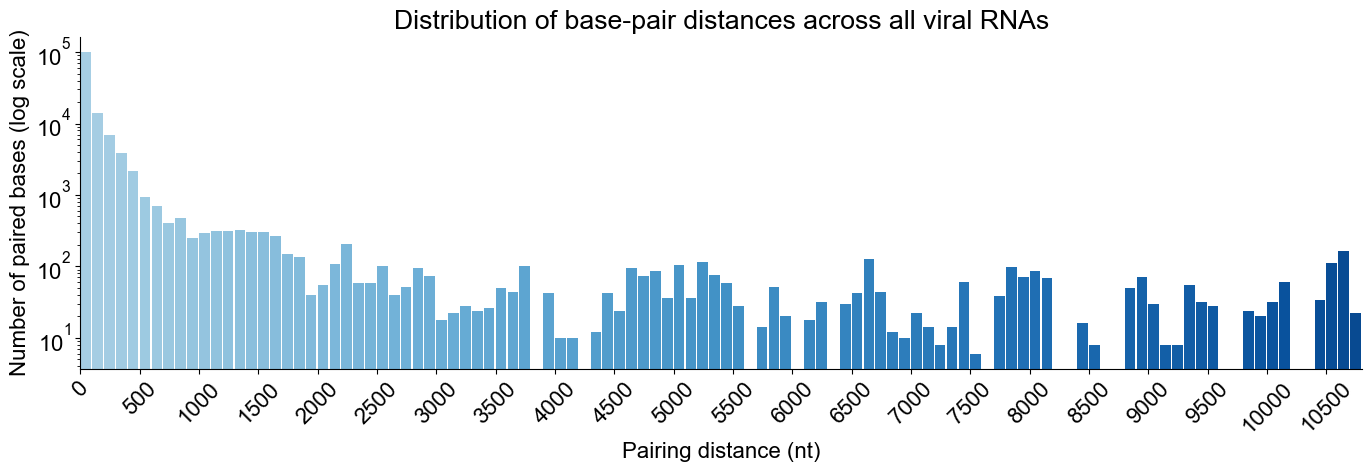

In [4]:
def bin_distances(distances, bin_size=BIN_SIZE):
    """Bin pairing distances into `bin_size`-nt intervals; `n_bases = 2 * n_pairs`."""
    n_bins = int(np.ceil(distances.max() / bin_size))
    bin_edges = np.arange(0, (n_bins + 1) * bin_size, bin_size)
    pair_counts, _ = np.histogram(distances, bins=bin_edges)
    return pd.DataFrame({
        "bin_start": bin_edges[:-1],
        "bin_end": bin_edges[1:],
        "distance_bin": [f"{int(bin_edges[i])}-{int(bin_edges[i + 1])}" for i in range(len(bin_edges) - 1)],
        "n_pairs": pair_counts,
        "n_bases": pair_counts * 2,
    })


bin_df = bin_distances(all_pair_distances, BIN_SIZE)

fig, ax = plt.subplots(figsize=(14, 5))
x, y = bin_df["bin_start"].to_numpy(), bin_df["n_bases"].to_numpy()
ax.bar(x, y, width=BIN_SIZE * 0.9, align="edge", color=plt.cm.Blues(np.linspace(0.35, 0.9, len(x))), edgecolor="none")
ax.set_xlabel("Pairing distance (nt)")
ax.set_ylabel("Number of paired bases (log scale)")
ax.set_title("Distribution of base-pair distances across all viral RNAs")
x_max = bin_df["bin_end"].iloc[-1]
ax.set_xlim(0, x_max)
ax.set_xticks(np.arange(0, x_max + 1, 500))
ax.tick_params(axis="x", rotation=45)
ax.set_yscale("log")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()


## Layered Recall by pairing-distance group



In [5]:
def calculate_layered_recall(ref_pairs, pred_pairs, low, high):
    """Recall over reference pairs with distance in `[low, high)`, matched with ±1 slack.

    Returns `(recall, n_ref_pairs)`; recall is NaN when the group is empty.
    """
    group_ref = [p for p in ref_pairs if low <= (p[1] - p[0]) < high]
    if len(group_ref) == 0:
        return np.nan, 0

    def matched(pair, others):
        return any(
            (pair[0] == o[0] and abs(pair[1] - o[1]) <= 1)
            or (pair[1] == o[1] and abs(pair[0] - o[0]) <= 1)
            for o in others
        )

    correct = sum(matched(p, pred_pairs) for p in group_ref)
    return correct / len(group_ref), len(group_ref)


PAIR_DISTANCE_GROUPS = [
    ("<200", 0, 200),
    ("200-499", 200, 500),
    ("500-999", 500, 1000),
    (">=1000", 1000, np.inf),
]


In [6]:
results_file = "results_virus_scores.xlsx"
results = pd.read_excel(results_file)

layered_xlsx_path = "pairing_distance_layered_recall.xlsx"

if os.path.isfile(layered_xlsx_path):
    sheets = []
    for group_name, _, _ in PAIR_DISTANCE_GROUPS:
        sheet_df = pd.read_excel(layered_xlsx_path, sheet_name=group_name)
        sheet_df["Group"] = group_name
        sheets.append(sheet_df)
    layered_recall_df = pd.concat(sheets, ignore_index=True)
else:
    layered_rows = []
    for _, row in results.iterrows():
        rna_id, method, pred_struct = row["ID"], row["Method"], row["Struct"]
        if rna_id not in viruses:
            continue
        ref_struct = viruses[rna_id][1]
        if len(ref_struct) != len(pred_struct):
            continue

        ref_pairs, ref_error = dot_bracket_to_pairs(clean_structure(ref_struct))
        pred_pairs, pred_error = dot_bracket_to_pairs(clean_structure(pred_struct))
        if ref_error or pred_error:
            continue

        for group_name, low, high in PAIR_DISTANCE_GROUPS:
            recall, n_ref = calculate_layered_recall(ref_pairs, pred_pairs, low, high)
            layered_rows.append([rna_id, method, group_name, recall, n_ref])

    layered_recall_df = pd.DataFrame(
        layered_rows, columns=["ID", "Method", "Group", "Recall", "n_ref_pairs"]
    )
    with pd.ExcelWriter(layered_xlsx_path) as writer:
        for group_name, _, _ in PAIR_DISTANCE_GROUPS:
            sheet_df = (
                layered_recall_df[layered_recall_df["Group"] == group_name]
                .drop(columns="Group")
                .reset_index(drop=True)
            )
            sheet_df.to_excel(writer, sheet_name=group_name, index=False)

print(f"Layered recall: {len(layered_recall_df)} rows → {layered_xlsx_path}")


Layered recall: 1284 rows → pairing_distance_layered_recall.xlsx


In [7]:
METHOD_GROUPS = [
    (
        "SF",
        [
            "EternaFold", "CONTRAfold", "RNAstructure", "LinearFold", "LinearPartition",
            "RNAfold", "CENTROIDFOLD", "ProbKnot", "ShapeKnots", "RNAshapes", "pKiss",
        ],
    ),
    ("DL", ["SPOT-RNA", "RFold"]),
    ("FM", ["ERNIE-RNA", "RiNALMo", "RNA-FM"]),
    ("Hybrid", ["rna-state-inf", "BPfold", "MXfold2", "KnotFold"]),
]

DISTANCE_GROUP_ORDER = [name for name, _, _ in PAIR_DISTANCE_GROUPS]

median_recall_mat = (
    layered_recall_df.groupby(["Method", "Group"])["Recall"]
    .median()
    .unstack()
    .reindex(columns=DISTANCE_GROUP_ORDER)
)
success_counts = results.groupby("Method").size().astype(int)


def order_methods_by_category(sort_key, ascending=False):
    grouped, ordered = [], []
    for cat, methods in METHOD_GROUPS:
        present = [m for m in methods if m in median_recall_mat.index]

        def sort_value(m, _key=sort_key):
            if m not in _key.index or pd.isna(_key.loc[m]):
                return -np.inf if not ascending else np.inf
            return float(_key.loc[m])

        present_sorted = sorted(present, key=sort_value, reverse=not ascending)
        if present_sorted:
            grouped.append((cat, present_sorted))
            ordered.extend(present_sorted)
    return grouped, ordered


## Recall across pairing-distance strata

Panel A: per-sequence reference pair counts by distance stratum. Panel B: per-method Recall boxplots; box/whisker color encodes within-method rank of bin-median Recall (deep → light purple = high → low).


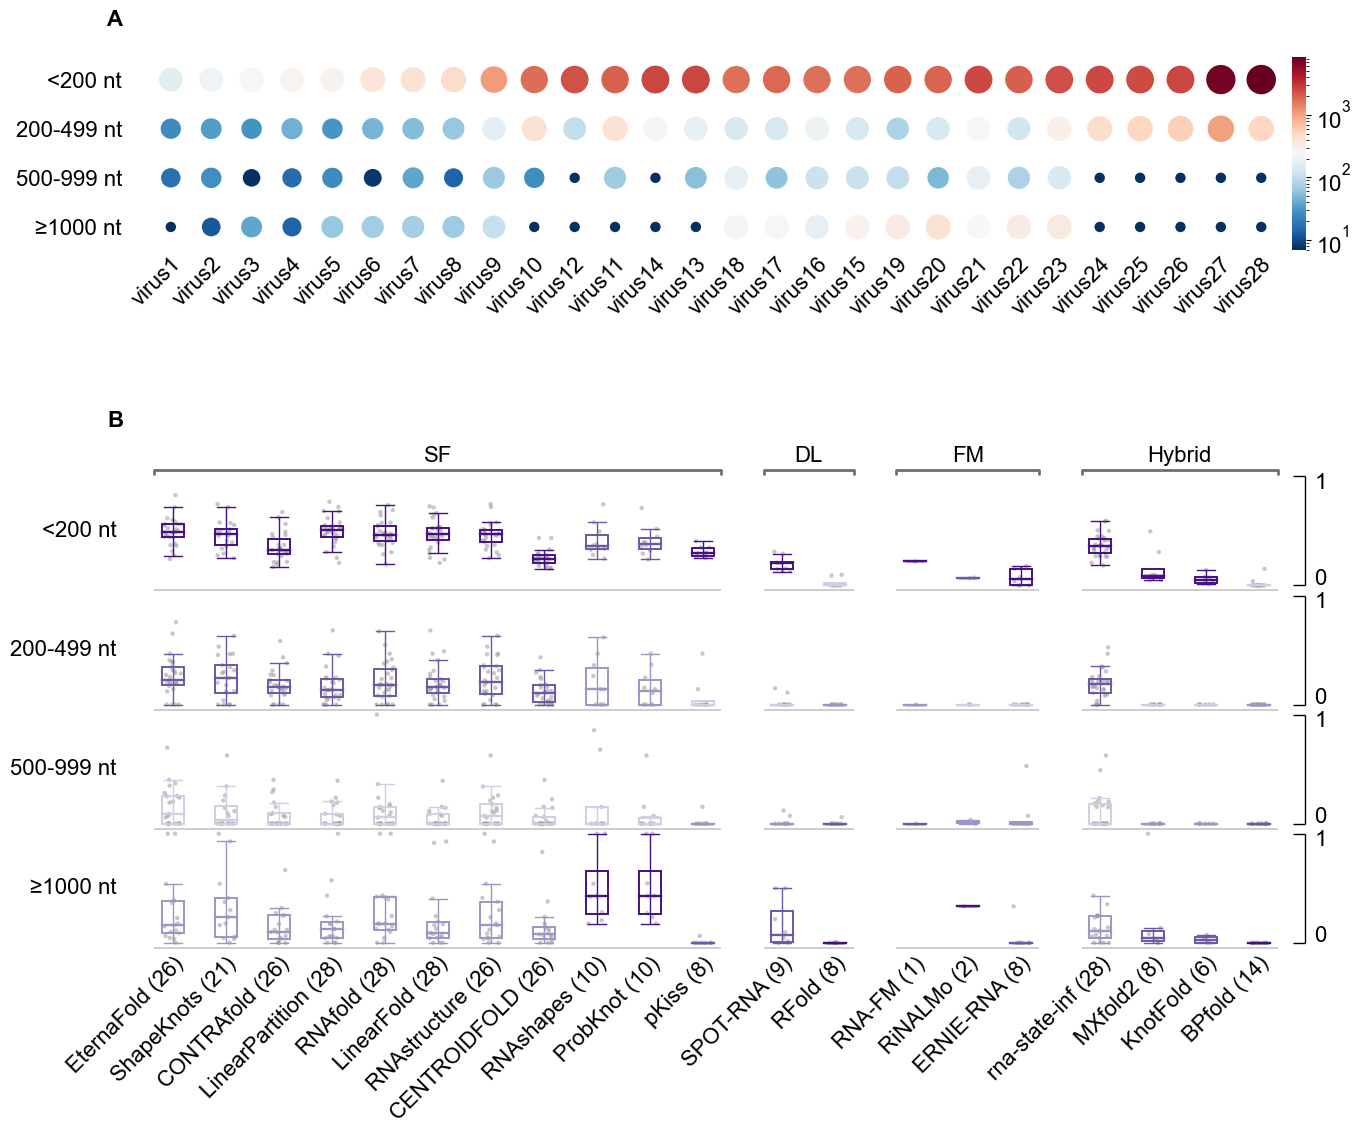

Saved figure to: fig/pairs_recall.pdf


In [8]:
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

seq_names_by_len = sorted(viruses.keys(), key=lambda k: len(viruses[k][0]))

pair_count_rows = []
for rna_id in seq_names_by_len:
    dists = np.asarray(pair_distances_by_id.get(rna_id, []), dtype=float)
    row = {}
    for gname, low, high in PAIR_DISTANCE_GROUPS:
        row[gname] = 0 if len(dists) == 0 else int(((dists >= low) & (dists < high)).sum())
    pair_count_rows.append(row)

pair_count_mat = pd.DataFrame(pair_count_rows, index=seq_names_by_len)
pair_count_vals = pair_count_mat.to_numpy(dtype=float)
pair_vmax = float(pair_count_vals.max())
pos_vals = pair_count_vals[pair_count_vals > 0]
pair_log_vmin = float(pos_vals.min()) if len(pos_vals) else 1.0

global_results = pd.read_excel("results_virus_scores.xlsx")
sort_key_f1 = global_results.groupby("Method")["F1"].median()
grouped_rec, ordered_methods = order_methods_by_category(sort_key_f1, ascending=False)

BIN_ROWS = list(DISTANCE_GROUP_ORDER)
bin_label = lambda g: {"<200": "<200 nt", ">=1000": "≥1000 nt"}.get(g, f"{g} nt")
fs = 16
POINT_GRAY = "#9A9A9A"
RANK_COLORS = list(plt.get_cmap("Purples")(np.linspace(0.95, 0.30, 4)))
Y_RECALL_LO, Y_RECALL_HI = 0.0, 1.0
cmap_pair = plt.get_cmap("RdBu_r")
norm_pair = LogNorm(vmin=pair_log_vmin, vmax=pair_vmax, clip=True)

CAT_GAP = 0.50
method_x, x_pos_list, cat_spans, _x = {}, [], [], 0.0
for cat, methods in grouped_rec:
    x_start = _x
    for m in methods:
        method_x[m] = _x
        x_pos_list.append(_x)
        _x += 1.0
    cat_spans.append((cat, x_start, _x - 1.0))
    _x += CAT_GAP
x_max = x_pos_list[-1]


def recall_values_for_method_bin(method, gname):
    return layered_recall_df.loc[
        (layered_recall_df["Method"] == method) & (layered_recall_df["Group"] == gname), "Recall"
    ].to_numpy(dtype=float)


box_edge_color = {}
for method in ordered_methods:
    meds = []
    for gname in BIN_ROWS:
        vals = recall_values_for_method_bin(method, gname)
        vals = vals[~np.isnan(vals)]
        meds.append(float(np.median(vals)) if len(vals) else np.nan)
    order = np.argsort(np.nan_to_num(np.asarray(meds, dtype=float), nan=-np.inf))[::-1]
    for rank, bin_i in enumerate(order):
        box_edge_color[(method, BIN_ROWS[bin_i])] = RANK_COLORS[min(rank, len(RANK_COLORS) - 1)]


def draw_v_boxplot_with_points(ax, values, x, edge, width=0.55):
    vals = np.asarray(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    lo_bound, hi_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    whisk_low, whisk_high = vals[vals >= lo_bound].min(), vals[vals <= hi_bound].max()
    rng = np.random.default_rng(abs(hash((float(x), float(med), len(vals)))) % (2**32))
    jitter = (rng.random(len(vals)) - 0.5) * width * 0.55
    ax.scatter(x + jitter, vals, s=10, c=POINT_GRAY, alpha=0.55, edgecolors="none", zorder=2, clip_on=False)
    ax.plot([x, x], [whisk_low, whisk_high], color=edge, lw=1.0, zorder=3, solid_capstyle="butt")
    cap_w = width * 0.28
    ax.plot([x - cap_w, x + cap_w], [whisk_low, whisk_low], color=edge, lw=1.0, zorder=3)
    ax.plot([x - cap_w, x + cap_w], [whisk_high, whisk_high], color=edge, lw=1.0, zorder=3)
    box_w = width * 0.7
    ax.add_patch(Rectangle((x - box_w / 2.0, q1), box_w, max(q3 - q1, 1e-4), facecolor="none", edgecolor=edge, linewidth=1.4, zorder=4))
    ax.plot([x - box_w / 2.0, x + box_w / 2.0], [med, med], color=edge, lw=1.7, zorder=5)


def style_b_row(ax, bin_name, show_xlabel=False, tick_positions=None):
    ax.set_ylim(Y_RECALL_LO - 0.02, Y_RECALL_HI + 0.02)
    ax.set_yticks([])
    ax.tick_params(axis="y", length=0, left=False, labelleft=False, right=False, labelright=False)
    ax.set_frame_on(False)
    ax.patch.set_alpha(0.0)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    _yx, _xl, _tick = ax.get_yaxis_transform(), 1.003, 0.010
    ax.plot([_xl, _xl], [Y_RECALL_LO, Y_RECALL_HI], transform=_yx, color="black", lw=1.0, solid_capstyle="butt", clip_on=False, zorder=1)
    ax.plot([_xl - _tick, _xl], [Y_RECALL_LO, Y_RECALL_LO], transform=_yx, color="black", lw=1.0, solid_capstyle="butt", clip_on=False, zorder=1)
    ax.plot([_xl - _tick, _xl], [Y_RECALL_HI, Y_RECALL_HI], transform=_yx, color="black", lw=1.0, solid_capstyle="butt", clip_on=False, zorder=1)
    ax.text(_xl + 0.008, Y_RECALL_LO + 0.06, "0", transform=_yx, ha="left", va="center", fontsize=fs, fontfamily=chosen_font, color="black", clip_on=False)
    ax.text(_xl + 0.008, Y_RECALL_HI - 0.06, "1", transform=_yx, ha="left", va="center", fontsize=fs, fontfamily=chosen_font, color="black", clip_on=False)
    ax.text(-0.012, 0.5, bin_label(bin_name), transform=ax.transAxes, ha="right", va="center", fontsize=fs, fontfamily=chosen_font, clip_on=False)
    ax.set_ylabel("")
    ax.set_xticks([] if tick_positions is None else tick_positions)
    if show_xlabel:
        ax.tick_params(axis="x", length=0, pad=6)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0)


fig = plt.figure(figsize=(14, 12), facecolor="white")
height_ratios = [0.85, 0.94, 0.50, 0.50, 0.50, 0.50]
gs = fig.add_gridspec(len(height_ratios), 2, height_ratios=height_ratios, width_ratios=[1.0, 0.012],
                      hspace=0.04, wspace=0.008, left=0.12, right=0.97, top=0.93, bottom=0.19)
ax_a = fig.add_subplot(gs[0, 0])
cax_a = fig.add_subplot(gs[0, 1])
axes_b = [fig.add_subplot(gs[2 + i, 0]) for i in range(4)]

n_seq = len(seq_names_by_len)
_ysp = 0.65
y_pos = {g: float(i) * _ysp for i, g in enumerate(BIN_ROWS)}
BUBBLE_S_MIN, BUBBLE_S_MAX = 160.0, 450.0
_log_lo = np.log10(max(pair_log_vmin, 1.0))
_log_hi = np.log10(max(pair_vmax, pair_log_vmin * 10.0))


def _bubble_size(val):
    if val <= 0:
        return BUBBLE_S_MIN * 0.35
    t = float(np.clip((np.log10(val) - _log_lo) / max(_log_hi - _log_lo, 1e-12), 0.0, 1.0))
    return BUBBLE_S_MIN + t * (BUBBLE_S_MAX - BUBBLE_S_MIN)


for xi, rna_id in enumerate(seq_names_by_len):
    for gname in BIN_ROWS:
        val = float(pair_count_mat.loc[rna_id, gname])
        facecolor = cmap_pair(0.0) if val <= 0 else cmap_pair(norm_pair(val))
        ax_a.scatter([xi], [y_pos[gname]], s=_bubble_size(val), c=[facecolor], edgecolors="none", linewidths=0, zorder=3)

ax_a.set_xlim(-1.0, n_seq)
ax_a.set_ylim(-0.30, (len(BIN_ROWS) - 1) * _ysp + 0.30)
ax_a.invert_yaxis()
ax_a.set_yticks([y_pos[g] for g in BIN_ROWS])
ax_a.set_yticklabels([bin_label(g) for g in BIN_ROWS], fontsize=fs, fontfamily=chosen_font)
ax_a.tick_params(axis="y", length=0, pad=6)
ax_a.set_xticks(range(n_seq))
ax_a.set_xticklabels(seq_names_by_len, rotation=45, ha="right", rotation_mode="anchor", fontsize=fs, fontfamily=chosen_font)
ax_a.tick_params(axis="x", length=0, pad=3)
for spine in ax_a.spines.values():
    spine.set_visible(False)
ax_a.text(-0.02, 1.14, "A", transform=ax_a.transAxes, fontsize=fs, fontweight="bold", fontfamily=chosen_font, va="bottom", ha="left", clip_on=False)

sm_a = ScalarMappable(cmap=cmap_pair, norm=norm_pair)
sm_a.set_array([])
cbar_a = fig.colorbar(sm_a, cax=cax_a)
cbar_a.set_label("")
cbar_a.ax.tick_params(labelsize=fs)
cbar_a.outline.set_visible(False)

trans_b0 = axes_b[0].get_xaxis_transform()
_y_br, _tick = 1.04, 0.04
for cat, x_start, x_end in cat_spans:
    x0, x1 = x_start - 0.35, x_end + 0.35
    axes_b[0].plot([x0, x1], [_y_br, _y_br], transform=trans_b0, color="#6f6f6f", linewidth=2.0, solid_capstyle="butt", clip_on=False, zorder=1)
    axes_b[0].plot([x0, x0], [_y_br - _tick, _y_br], transform=trans_b0, color="#6f6f6f", linewidth=2.0, solid_capstyle="round", clip_on=False, zorder=1)
    axes_b[0].plot([x1, x1], [_y_br - _tick, _y_br], transform=trans_b0, color="#6f6f6f", linewidth=2.0, solid_capstyle="round", clip_on=False, zorder=1)
    axes_b[0].text((x0 + x1) / 2.0, _y_br + 0.03, cat, transform=trans_b0, ha="center", va="bottom", fontsize=fs, fontfamily=chosen_font, color="#000000", clip_on=False)

for row_i, gname in enumerate(BIN_ROWS):
    ax = axes_b[row_i]
    for method in ordered_methods:
        draw_v_boxplot_with_points(ax, recall_values_for_method_bin(method, gname), method_x[method], box_edge_color[(method, gname)], width=0.60)
    ax.set_xlim(-0.8, x_max + 0.8)
    style_b_row(ax, gname, show_xlabel=(row_i == 3), tick_positions=x_pos_list)

axes_b[3].set_xticklabels(
    [f"{m} ({int(success_counts.get(m, 0))})" for m in ordered_methods],
    rotation=45, ha="right", rotation_mode="anchor", fontsize=fs, fontfamily=chosen_font,
)
axes_b[0].text(-0.02, 1.38, "B", transform=axes_b[0].transAxes, fontsize=fs, fontweight="bold", fontfamily=chosen_font, va="bottom", ha="left", clip_on=False)

fig.canvas.draw()
_pos_a = cax_a.get_position()
cax_a.set_position([_pos_a.x0 - 0.010, _pos_a.y0, _pos_a.width, _pos_a.height])
_inv_fig = fig.transFigure.inverted()


def _draw_sep_at(y_fig):
    for _cat, x_start, x_end in cat_spans:
        d0 = axes_b[0].transData.transform((x_start - 0.35, 0.0))
        d1 = axes_b[0].transData.transform((x_end + 0.35, 0.0))
        fx0, _ = _inv_fig.transform(d0)
        fx1, _ = _inv_fig.transform(d1)
        fig.add_artist(plt.Line2D([fx0, fx1], [y_fig, y_fig], transform=fig.transFigure, color="#C0C0C0", linewidth=1.1, solid_capstyle="butt", clip_on=False, zorder=0))


for i in range(3):
    b_upper, b_lower = axes_b[i].get_position(), axes_b[i + 1].get_position()
    _draw_sep_at(0.5 * (b_upper.y0 + b_lower.y1))
_gap = axes_b[2].get_position().y0 - axes_b[3].get_position().y1
_draw_sep_at(axes_b[3].get_position().y0 - 0.5 * _gap)

out_path = os.path.join(FIG_DIR, "pairs_recall.pdf")
plt.savefig(out_path, format="pdf", dpi=350)
plt.show()
print(f"Saved figure to: {out_path}")
